# Alma Analytics Catalog File Parser

This R notebook provides a GitHub-friendly walkthrough of the Alma Analytics `.catalog` parsing pipeline. GitHub renders the annotations, R code cells, and saved outputs directly in the repository.

## Project overview for the team

This project converts a compressed Ex Libris Alma Analytics `.catalog` export—embedded XML plus catalog metadata—into auditable, spreadsheet-friendly documentation of saved filters and saved columns.

> **Team summary:** The project opens Alma catalog exports, preserves the original definitions, translates technical XML expression trees into readable business rules, and supports the creation of campus-specific exclusions documentation.

There are two connected workflows:

1. **Automated parsing:** `.catalog` file → complete XML/metadata extract → general column and filter inventories → readable rule tables.
2. **Reviewed publication:** parser outputs → manually enriched normalized workbook → campus-specific exclusions workbooks.

The parser is the reproducible source-extraction layer. The normalized workbook is an important human-review checkpoint because campus scope, domain, review labels, and explanations cannot always be inferred safely from Alma XML.

## Why the `.catalog` file needs a parser

Although an Alma Analytics `.catalog` file contains XML-based catalog objects, the archive itself is not readable as plain-text XML. Opening it directly in a text editor displays binary content rather than usable report definitions.

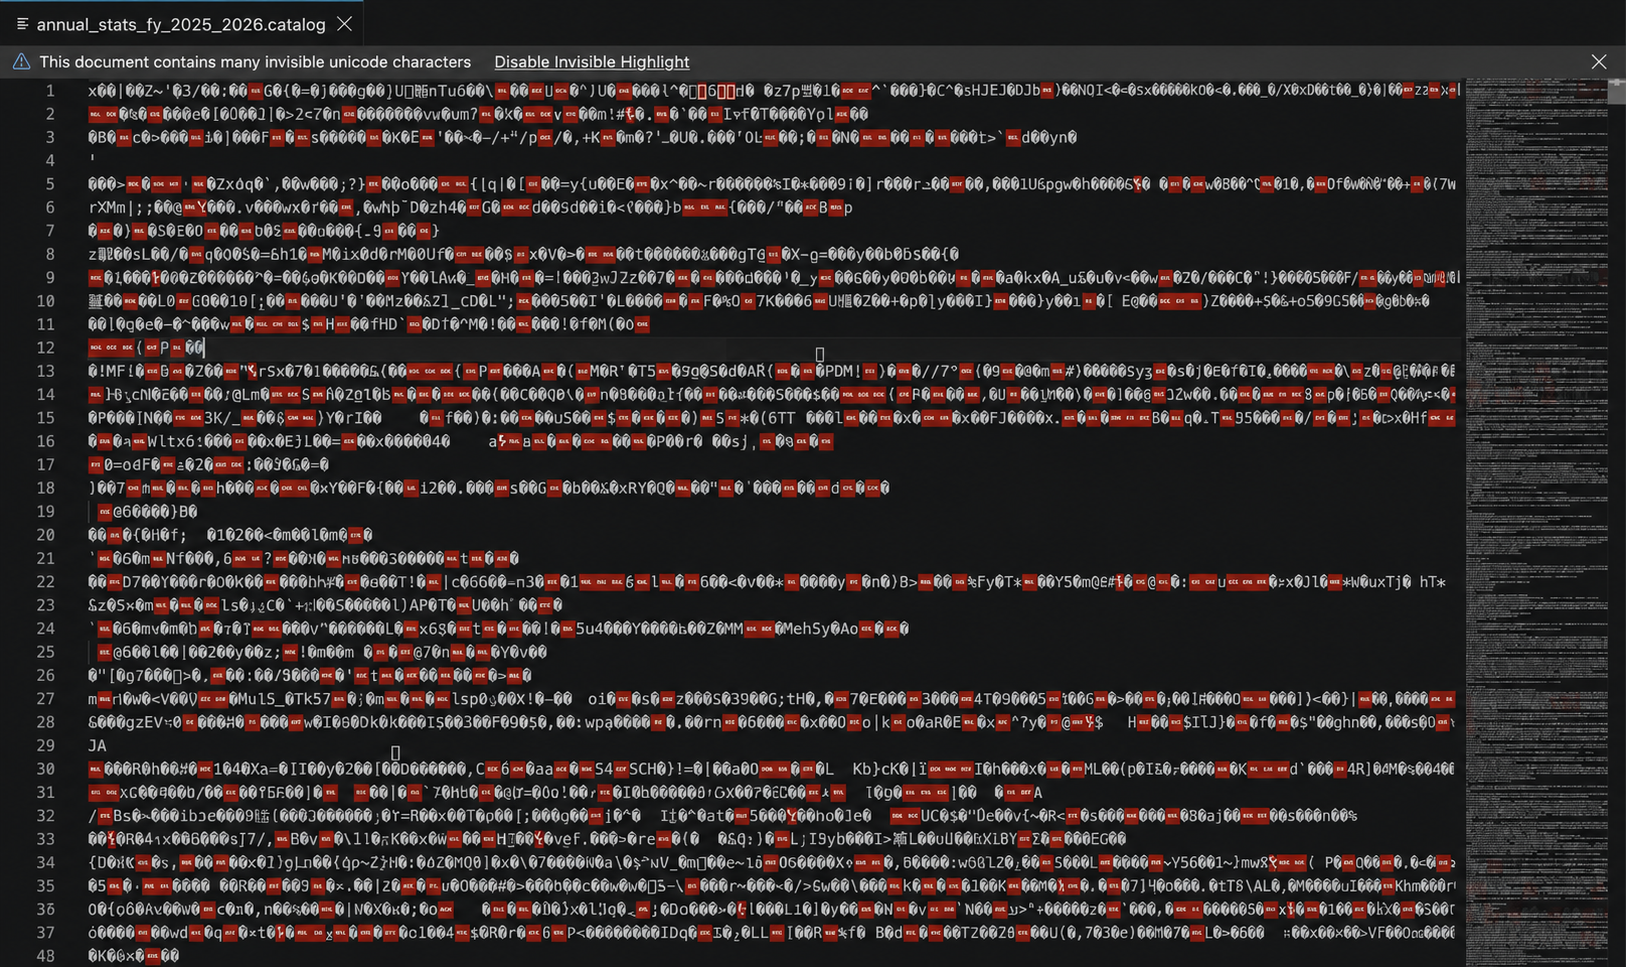

The parser decompresses the archive, finds the embedded XML objects, aligns them with their catalog metadata, and converts their definitions into reviewable datasets. The appearance shown above is expected and does not mean that the `.catalog` file is corrupted.

## Alma Analytics Criteria Export Options

**Alternative Methods considered:**

On June 9, 2026, Kristen ([@kristenchua-commits](https://github.com/kristenchua-commits)) and the UC Libraries Annual Statistics Project Team consulted with Gem and Chris Groskopf ([@onyxfish](https://github.com/onyxfish)) from the UC Libraries SILS Operations Team to discuss approaches for extracting Alma Analytics criteria data. The SILS Operations Team noted that the Alma Analytics API has historically been used to retrieve report results rather than the underlying report criteria, and that there was no established institutional approach for extracting criteria metadata. When asked how experienced Alma Analytics developers typically work with Analytics metadata, the advisors indicated that implementation is largely a matter of practitioner preference.

The initial parser was implemented in R because it enabled the fastest development and validation of a working prototype. The project primarily performs XML parsing, hierarchical metadata reconstruction, data transformation, and export to tabular documentation formats—all tasks that are well supported by base R and the **xml2** package used by the parser. Leveraging existing expertise allowed the project team to focus on understanding the undocumented `.catalog` format rather than simultaneously learning a new programming language.

The parser's overall architecture is language independent. Its modular design, documented intermediate data structures, retained source XML, and standardized CSV and Excel outputs make the implementation portable. Although a Python implementation could provide broader familiarity within the library software community, the underlying parsing strategy and processing pipeline are not dependent on R and could be reimplemented in another language if future maintenance or institutional requirements warrant it.

- In late June and early July 2026, Kristen created the Alma Analytics catalog file parser GitHub repository to enable collaborative sharing of code and outputs. During this period, Kristen also optimized the processing pipeline by making the scripts modular and implementing a decision tree that makes a `.catalog` file readable as XML, traverses the XML tree, and applies object-specific criteria-parsing logic based on the Alma Analytics object type, including saved columns, saved filters, analyses, and other objects.

| Criterion | `.catalog` R-based parser | Manual export |
|---|---|---|
| Ability to expose report-filter and saved-object criteria | **Yes** | **Yes** |
| Automation | **Moderate.** A technical team member must download the `.catalog` file and run the R files that parse it. | **Weak.** Staff must inspect and document objects individually. |
| Initial development | **High.** Requires development and validation of the parser. | **Low.** Requires training staff to navigate the Alma Analytics folder structure, open objects, and locate their criteria. |
| Annual staff effort | **Current maintenance effort: Low after setup**, assuming the `.catalog` structure remains unchanged.<br><br>**Long-term maintenance effort: Unknown and potentially high.** The parser depends on the current compressed-file structure, metadata fields, XML boundaries, object signatures, and expression formats. Because this is not a documented public interface, Ex Libris could change it without maintaining compatibility with the parser. | **High.** Staff must use the Alma Analytics interface and manually copy and paste criteria each year or whenever a change is made. |
| Auditability | **Moderate to strong.** The source `.catalog` XML is retained and its surrounding metadata contains per-object fields such as `CreatedTime` and `LastModifiedTime`. However, the `.catalog` contents do not include the time at which the archive itself was exported. GitHub commit history for source files—for example, `data/examples/annual_stats_fy_2025_2026.catalog`—shows when a file was added to the project, although that is an ingestion timestamp rather than an export timestamp. | **Low to moderate.** Criteria and filters are copied manually from Alma Analytics, and there is no static source snapshot as Analytics data and configurations change. See *Analytics Database Refresh* in the Ex Libris Knowledge Center. |
| Change tracking | Script and output changes are managed through the GitHub workflow. Input history is represented by commits to source `.catalog` files, which show when each snapshot was added to the project. | Changes are recorded in Google Sheets snapshots when updates are made. Alma Analytics does not directly provide this documentation history, although relevant activity might be available through an audit log and requires further investigation. |
| Format complexity — how difficult the exported file or response is to transform into a reliable, analysis-ready table | **High.** The `.catalog` export is a compressed container of metadata and hierarchical XML. Specialized parsing is required to match objects with metadata, reconstruct nested reporting logic, and transform it into relational tables. | **Low technical complexity, high manual effort.** No specialized parsing is required, but a person must open each Analytics object and copy its criteria individually. The process is slow, tedious, difficult to reproduce, and susceptible to omissions or inconsistent transcription. |
| Reproducibility | **Strong if scripted.** | **Weak.** |
| Human checking still needed | **Yes.** | **Yes.** |

### .catalog R-based parser Operationalization options

The options for operationalizing the `.catalog` R-based parser are:

| Criteria | **GitHub download-and-run approach** | **Web application approach** |
|---|---|---|
| Accessibility | **Con:** Staff must download the full repository, understand its structure, edit file paths, and run R locally. This is less accessible to nontechnical and occasional users. | **Pro:** Staff use a simple upload-and-process interface without interacting directly with R, GitHub, or repository paths. |
| Setup | **Con:** Each user must install R and required packages, maintain a local copy of the repository, and configure paths correctly. | **Pro:** Users need only a browser. **Con:** The organization must deploy, configure, and support the application and its R runtime. |
| Staff workflow | **Con:** Downloading, configuring, running, locating outputs, and repeating the process is cumbersome and increases the likelihood of setup and path errors. | **Pro:** Staff upload an Alma Analytics `.catalog` file, the application runs the existing R parser automatically, and the resulting files are presented for download. |
| Reproducibility | **Con:** Results can vary when users have different repository versions, package versions, paths, or local configurations. | **Pro:** A centrally managed parser version and execution environment provide a more consistent and reproducible workflow across users. |
| Maintenance | **Con:** Repository or file-location changes can require updated instructions and local changes for every user. **Pro:** GitHub provides transparent source control and change history. | **Pro:** Parser and interface updates are made once in the centrally deployed application. **Con:** Hosting, package updates, monitoring, and application maintenance become ongoing responsibilities. |
| Suitability for occasional users | **Con:** The amount of setup is inefficient for staff who run the parser infrequently. | **Pro:** The upload-and-download workflow is well suited to occasional use and a shared internal service. |
| Processing capability | **Pro:** Users can run and inspect the complete R-based parsing pipeline locally, which is useful for developers and advanced troubleshooting. | **Pro:** The application can invoke the same R-based parser to extract criteria, saved columns, filters, bins, and related reporting-object metadata without duplicating parsing logic. |
| Reusable outputs | **Pro:** The parser writes CSV and Excel files directly to the user's configured local output directory. | **Pro:** The application can package the extracted metadata as downloadable CSV or Excel files immediately after processing. |
| Governance and security | **Pro:** Source files remain on the user's workstation. | **Con:** The application requires appropriate access controls, secure temporary-file handling, upload limits, retention rules, and an approved internal hosting environment. |
| Overall assessment | Best retained as a developer, validation, and fallback workflow, but comparatively cumbersome as the primary staff-facing process. | Recommended prototype for a shared internal workflow, provided that hosting, security, and operational support requirements can be met. |

### Future directions

Available documentation indicates that the API returns the results of executed Alma Analytics reports, rather than their underlying filter criteria or saved report definitions. Further testing is required because the parser's creator ([@kristenchua-commits](https://github.com/kristenchua-commits)) had not yet been granted API access to verify these limitations directly as of July 2026.

## How to use this notebook

1. Put the `.catalog` file you want to process in `data/uploads/`. In the GitHub website, open that folder and choose **Add file → Upload files**. In a local clone, copy the file into the same folder using Finder.
2. Open this notebook from the repository root in Jupyter with an R kernel, VS Code, or another notebook environment. GitHub can display the notebook, but it does not run the R parser.
3. Change only the `catalog_path` value in the configuration cell below so its filename exactly matches the uploaded file. You do not need to edit any files under `R/` or `scripts/`.
4. Leave `output_dir <- "output"` unchanged unless you intentionally want the generated files written somewhere else.
5. Run the cells from top to bottom. The parser writes its CSV, Excel, and RDS outputs into `output/`.
6. Save the executed notebook and commit it if you want GitHub to display the refreshed cell outputs.

An R Jupyter kernel can be installed from R with `install.packages('IRkernel')` followed by `IRkernel::installspec()`. Before uploading a `.catalog` file to GitHub, confirm that the repository's access controls are appropriate for the report definitions and metadata it contains.

## Configure the input and output

Upload the .catalog file to the data folder(https://github.com/kristenchua-commits/alma-analytics-catalog-file-parser-project/tree/main/data).

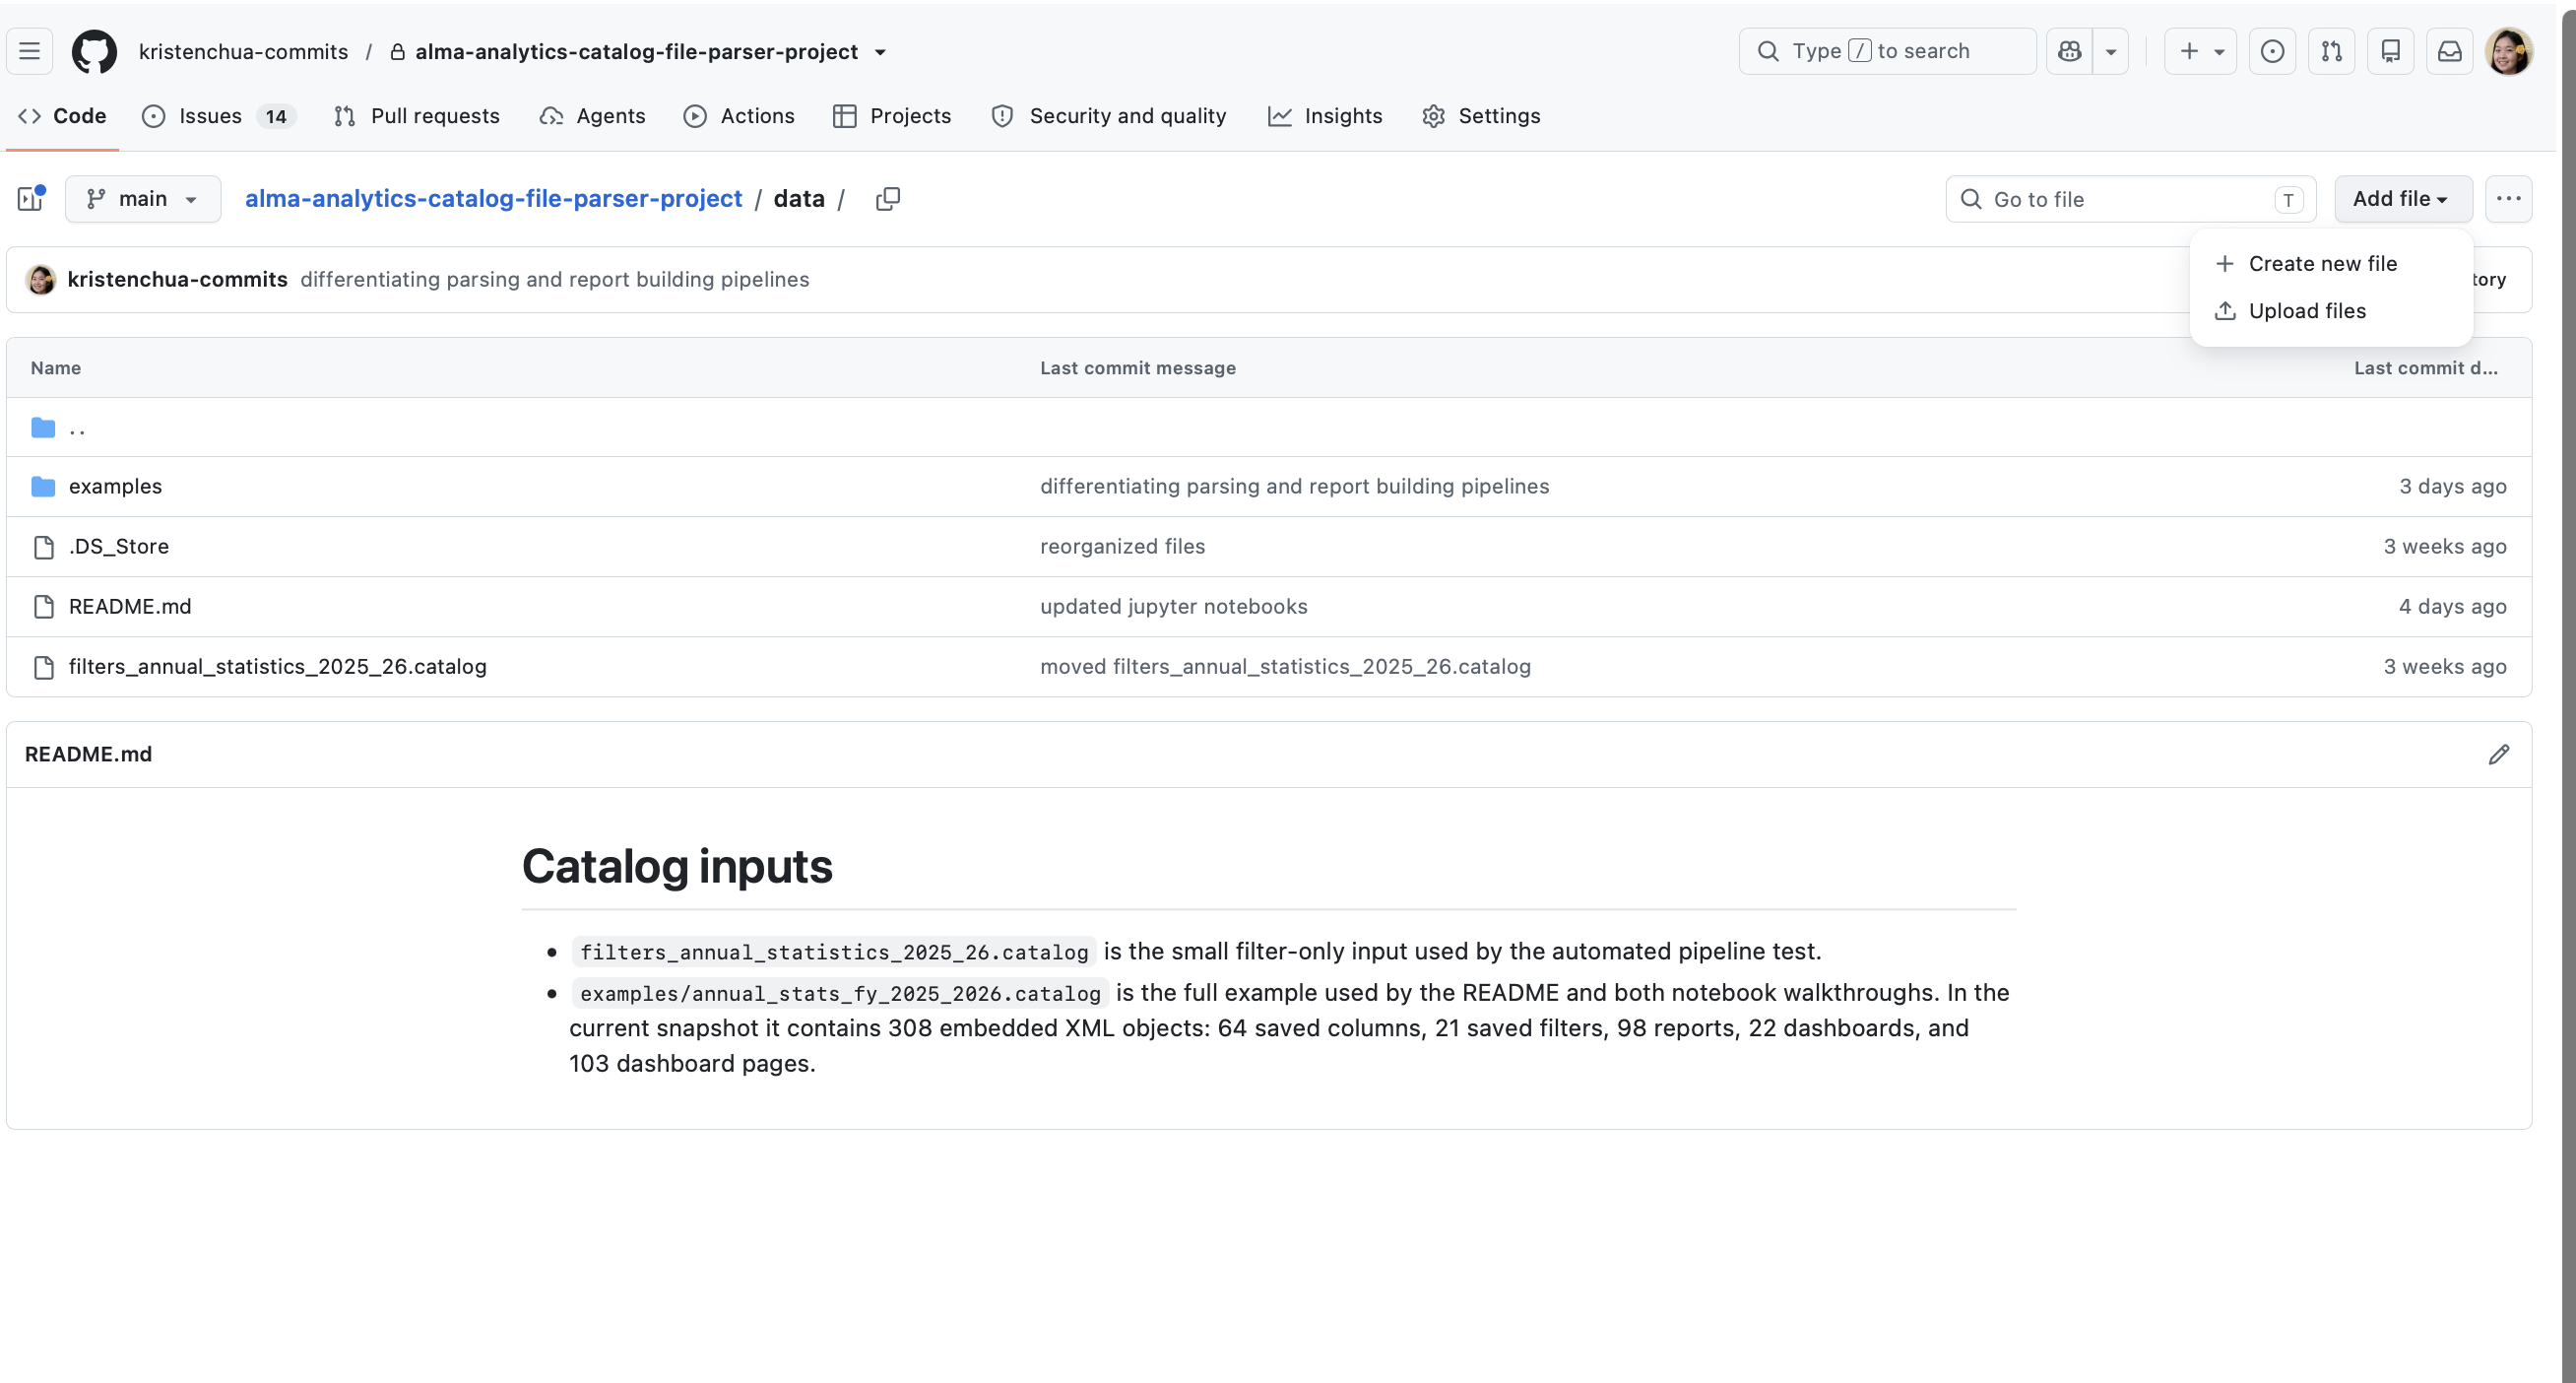


- To run the included demonstration file, leave `catalog_path` as `data/examples/annual_stats_fy_2025_2026.catalog`.
- To run your own file, upload it to `data/uploads/` and replace the value with `data/uploads/<your exact filename>.catalog`.
- Keep the quotation marks around the path. Filenames are case-sensitive on some systems.
- `output_dir <- "output"` means the generated files will be written to the repository's `output/` folder.

For example, if you upload `FY2026_catalog_export.catalog`, use:

```r
catalog_path <- "data/uploads/FY2026_catalog_export.catalog"
output_dir <- "output"
```

In [ ]:
# Included demonstration file:
catalog_path <- "data/examples/annual_stats_fy_2025_2026.catalog"

# To process your own upload, replace the line above, for example:
# catalog_path <- "data/uploads/FY2026_catalog_export.catalog"

output_dir <- "output"

if (!file.exists(catalog_path)) {
  stop("Catalog file not found: ", catalog_path)
}

catalog_path

### Optional interactive selection in RStudio

Instead of setting `catalog_path` manually, the wrapper can search the repository `data/` directory and `~/Downloads`, then present a menu. This is intended for an interactive RStudio session, so the cell remains commented out during unattended notebook execution.

In [ ]:
# source("scripts/choose_catalog_file_and_run_pipeline.R")
# catalog <- run_catalog_pipeline()

## Run the pipeline

The wrapper validates the selected file and calls the underlying `run_parsing_pipeline()` engine. The engine does more than simply read a file:

1. `read_catalog_file()` decompresses the raw `.catalog` file, finds every embedded `<?xml` block, parses its root element, and returns one row per XML object.
2. `read_catalog_metadata()` extracts the matching catalog metadata record, including the object title, path, and `ObjectSignature`. Folder-only metadata is excluded from the XML object table.
3. The XML root name and metadata signature are used together to classify every object.
4. The complete object table is saved to `catalog_extract.rds` and `catalog_extract_summary.csv`.
5. Saved columns and saved filters are sent to their specialized parsers. Reports, dashboards, and dashboard pages remain available in the catalog extract and summary.

In [ ]:
source("scripts/choose_catalog_file_and_run_pipeline.R")

catalog <- run_catalog_pipeline(
  catalog_path = catalog_path,
  output_dir = output_dir
)

Example validated run: parsed 308 catalog objects and wrote outputs under output/.


## Automated parser pipeline map


This diagram covers the automated `.catalog` parser. The arrows show the direction of processing. Blue identifies the original input, green identifies processing scripts, yellow identifies intermediate datasets used by later stages, purple identifies human-facing review outputs, and gray identifies inspection or detailed technical outputs. The reviewed normalization and campus-publication stages are listed in the table and documented separately below.

The optional `scripts/choose_catalog_file_and_run_pipeline.R` entry point finds or prompts for a `.catalog` file and passes its path to `scripts/run_parsing_pipeline.R`. The command-line script loads the reusable orchestrator in `R/run_parsing_pipeline.R`, which sources the processing functions and calls them in dependency order. A noninteractive run can call `Rscript scripts/run_parsing_pipeline.R path/to/file.catalog [output_dir]` directly.

| Stage | Script(s) | Reads | Writes |
|---|---|---|---|
| Input selection and orchestration | `scripts/choose_catalog_file_and_run_pipeline.R`; `scripts/run_parsing_pipeline.R`; `R/choose_catalog_file.R`; `R/run_parsing_pipeline.R` | Raw Alma Analytics `.catalog` file | Starts the shared extraction stage |
| Shared catalog extraction | `R/extract/extract_catalog.R`; `R/io/read_catalog_file.R`; `R/io/read_catalog_metadata.R` | `.catalog` file | `catalog_extract.rds`; `catalog_extract_summary.csv` |
| Metadata and XML-tag inspection | `R/inspect/inspect_catalog_metadata.R`; `R/extract/extract_xml_tag_inventory.R` | `catalog_extract.rds` | `catalog_metadata_inventory.csv`; `xml_tag_inventory.csv` |
| General column parsing | `R/extract/extract_columns.R` | Reports and saved columns in `catalog_extract.rds` | `columns.csv`; `column_rules.csv` |
| General filter parsing | `R/extract/extract_filters.R` | Reports and saved filters in `catalog_extract.rds` | `filters.csv`; `filter_rules.csv`; `filter_value_lists.csv` |
| Report dependencies | `R/export/export_report_dependencies.R` | General column and filter results | `report_dependencies.csv` |
| Reviewed normalization | Manual review in `output/normalized_combined_saved_column_and_filter_review.xlsx` | Column and filter rule rows | Campus, domain, labels, explanations, and campus worksheets |
| Campus documentation publication | `scripts/export_documentation/export_exclusions_documentation.R` | Reviewed normalized workbook and source `.catalog` file | One exclusions-documentation workbook per `UC*` worksheet |

`catalog_extract.rds` is the shared foundation for the general column and filter branches. Each branch includes inline report definitions, report references to saved objects, and every standalone saved object, including objects that no report references.

The general branches are conditional. `run_parsing_pipeline.R` runs a branch when reports or the corresponding standalone saved objects are present. Dashboards, dashboard pages, and unrecognized objects remain available in `catalog_extract.rds` and `catalog_extract_summary.csv`.

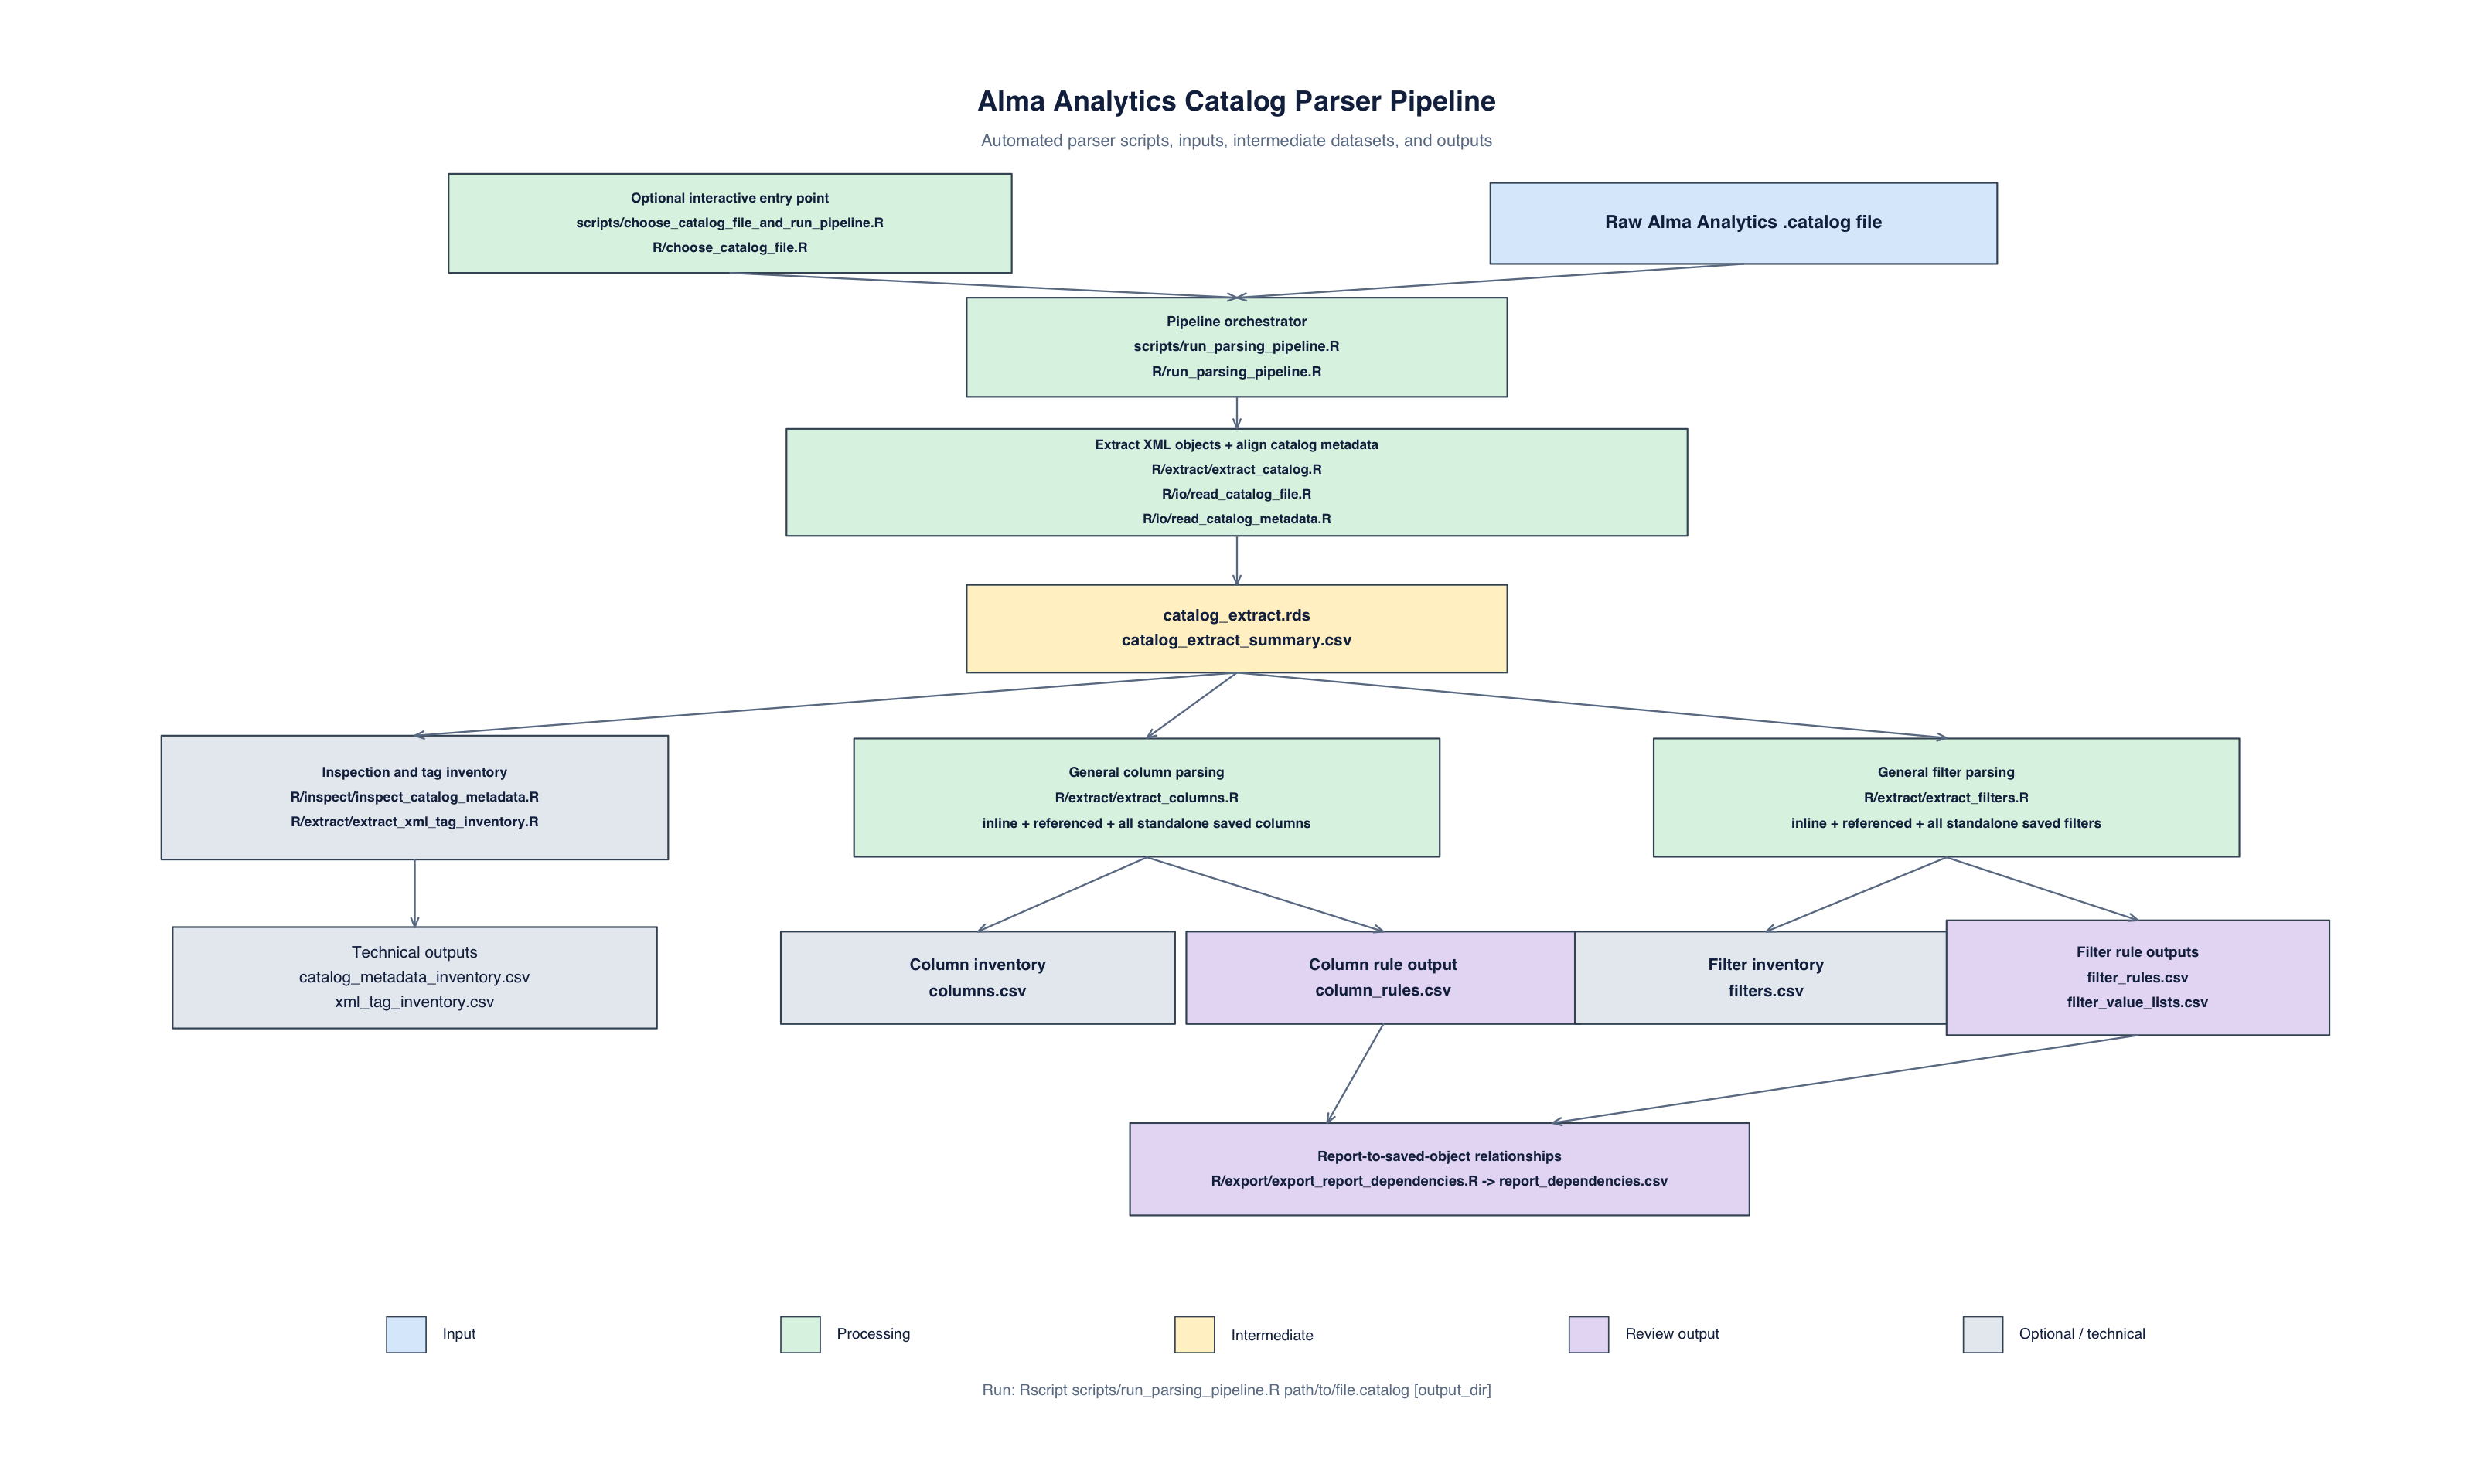

In [ ]:
# Embedded pipeline diagram for GitHub and Jupyter previews.


### How object types are identified

Classification happens in `read_catalog_metadata.R`. The parser checks both `xml_root_name` and `object_signature`, because saved filters and saved columns can be identified by either source. Exact XML root names are used for reports and dashboard objects.

| Classification | Detection rule | Downstream behavior |
|---|---|---|
| `filter` | Root name or signature contains `filter` | Included in `filters.csv` and expanded into `filter_rules.csv` even when unreferenced |
| `saved_column` | Root name or signature contains `column` | Included in `columns.csv` and expanded into `column_rules.csv` even when unreferenced |
| `dashboard_page` | Root name is exactly `dashboardPage` | Retained in the catalog extract and summary |
| `dashboard` | Root name is exactly `dashboard` | Retained in the catalog extract and summary |
| `report` | Root name is exactly `report` | Inline definitions and saved-object references feed the general column and filter branches |
| `other` | No preceding rule matches | Retained for inspection rather than discarded |

In [ ]:
classification_check <- aggregate(
  catalog_index ~ object_kind,
  data = catalog,
  FUN = length
)
names(classification_check)[2] <- "object_count"
classification_check

     object_kind object_count
1      dashboard           22
2 dashboard_page          103
3         filter           21
4         report           98
5   saved_column           64


### How the pipeline branches after classification

The engine checks whether any `saved_column` or `filter` rows exist before running their exporters. This prevents irrelevant exports for catalogs that contain only one object family.

- **Saved columns:** XML `when`, `condition`, `value`, and `otherwise` nodes are converted into SQL-formatted bin criteria and labels, using operators such as `=`, `IN`, `IS NULL`, and `LIKE`.
- **Saved filters:** expression trees are parsed into readable criteria; very large `IN` value lists are summarized in the workbook and retained in a companion CSV.
- **Reports and dashboards:** their XML and metadata remain in `catalog_extract.rds`; their titles, paths, hierarchy, and types remain in the summary CSV.

## Preview the extracted catalog

Each row represents one XML-backed Alma Analytics object. The hierarchy columns identify the nearest containing folder and catalog item.

In [ ]:
preview_columns <- c(
  "catalog_index", "object_title", "object_kind",
  "closest_folder", "closest_level_object"
)

head(catalog[preview_columns], 10)

  catalog_index object_kind   object_title
1             1 saved_column Electronic - Count of Electronic Holdings
2             2 saved_column Electronic - Count of Electronic Titles
3             3 report       test2 UCB physical holdings and titles report (no SLF)
4             4 dashboard    dashboard layout
5             5 dashboard    dashboard layout


## Count objects by type

This provides a quick check that reports, dashboards, filters, and saved columns were classified successfully.

In [ ]:
object_counts <- as.data.frame(
  table(catalog$object_kind),
  stringsAsFactors = FALSE
)
names(object_counts) <- c("object_kind", "object_count")
object_counts

     object_kind object_count
1      dashboard           22
2 dashboard_page          103
3         filter           21
4         report           98
5   saved_column           64


## Review generated files

The most useful human-facing outputs are `column_rules.csv`, `filter_rules.csv`, and `catalog_extract_summary.csv`.

In [ ]:
generated_files <- data.frame(
  file = list.files(output_dir, full.names = TRUE),
  stringsAsFactors = FALSE
)
generated_files

## What the validated example produces

The full example catalog was verified against the current code. It contains 308 XML-backed objects and exercises both conditional review branches.

| Result | Count |
|---|---:|
| Saved columns | 64 |
| Filters | 21 |
| Reports | 98 |
| Dashboards | 22 |
| Dashboard pages | 103 |
| Column records | 761 |
| Column rule rows | 903 |
| Filter records | 315 |
| Filter rule rows | 323 |
| Individual filter-list values | 150,880 |
| Inventoried XML tags | 163,097 |

`columns.csv`, `filters.csv`, and `xml_tag_inventory.csv` are detailed technical/audit outputs. `column_rules.csv` and `filter_rules.csv` are the concise human-review outputs. Large `IN` and `NOT IN` lists are kept in `filter_value_lists.csv` so individual CSV cells remain readable.

## Continue to campus documentation publication

The automated parser ends with the general column and filter rule outputs. After those outputs have been combined, enriched, and reviewed, continue in [`campus_saved_column_filter_documentation_construction.ipynb`](campus_saved_column_filter_documentation_construction.ipynb). That separate notebook validates the normalized workbook, previews the campus-specific output names, runs the publication script only when explicitly enabled, and lists the documentation workbooks it creates.

## Current project status and handoff notes

### What is working

- The automated filter-only fixture test passes, including its base-R fallback when `testthat` is unavailable.
- The complete example pipeline runs successfully and reproduces the counts above.
- Full source XML is retained in RDS files, so translated rules remain auditable.
- The reader stops when XML and metadata counts do not match instead of silently pairing records incorrectly.

### What still needs attention

- The old saved-column and saved-filter branches have been replaced by general column and filter branches that include inline, referenced, and standalone objects.
- No script currently creates the normalized combined workbook from raw parser outputs. Its manual classification and campus assignments are not yet reproducible from code alone.
- Automated coverage checks both general branches and unreferenced standalone objects, but does not exhaustively validate normalized-workbook transformations.
- Dashboards are retained and inventoried, but do not have a dedicated human-review exporter.

### Suggested explanation in a team meeting

> Alma's catalog export is a compressed container of XML objects and metadata, not a clean reporting dataset. This project opens that container, matches each definition to its Alma name and path, and preserves the source. It translates saved-column formulas and nested filters into a shared business-rule format. Staff then enrich that format with campus, domain, labels, and explanations before the project publishes campus-specific exclusions documentation. The parser is working and reproducible; the next maturity step is to automate and test the normalization layer so the complete publication workflow has traceable lineage.